In [19]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import plotly_express as px
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.decomposition import NMF, PCA
from sklearn.preprocessing import normalize
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

from scipy.stats import binom
from scipy.cluster.hierarchy import to_tree
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from scipy.spatial.distance import pdist

import sys
sys.path.append("../../local_lib/")
from hac2 import HAC
from heatmap import plot_grid, plot_map, CorrelationHeatMap as CHM

In [20]:
DOC = pd.read_csv("ajtzibab-CHUNK.csv")

In [21]:
doc_str = 'chunk_str'
token_pattern = r"(?u)\b\w[\w']*\b"
min_ngram = 1
max_ngram = 2

In [22]:
count_engine = CountVectorizer(ngram_range=(min_ngram, max_ngram), token_pattern=token_pattern)

In [23]:
CTM = pd.DataFrame(count_engine.fit_transform(DOC[doc_str]).toarray(), 
                   index=DOC.index, 
                   columns=count_engine.get_feature_names_out())

In [24]:
VOCAB = CTM.sum().to_frame('n')
VOCAB.index.name = 'term_str'
VOCAB['grams'] = VOCAB.apply(lambda x: len(x.name.split()), axis=1)

In [25]:
VOCAB

,n,grams
term_str,,
a,30,1
a are,1,2
a chikik,1,2
a e,1,2
a na,2,2
...,...,...
yojol,3,1
yojol juyub,2,2
yojol rech,1,2


In [26]:
VOCAB['df'] = CTM.astype(bool).sum() # p(w)
VOCAB['dp'] = VOCAB.df / len(CTM) # p(d|w)
VOCAB['dh'] = VOCAB.dp * np.log2(1/VOCAB.dp)

In [27]:
px.scatter(VOCAB.reset_index(), 'n', 'dh', log_x=True, width=600, hover_name='term_str')

In [28]:
max_entropy = VOCAB.dh.quantile(.8).round(2)
max_entropy = .11
max_entropy

0.11

In [29]:
stop_mask = VOCAB.dh <= max_entropy
SIGS = VOCAB[~stop_mask & (VOCAB.n > 1)].index.tolist()
stopwords = VOCAB[stop_mask].index.tolist()

In [30]:
CTMX = CTM[SIGS]
tfidf_engine = TfidfTransformer(norm='l2', use_idf=True, smooth_idf=True)
TFIDF = pd.DataFrame(tfidf_engine.fit_transform(CTMX).toarray(), columns=CTMX.columns, index=CTMX.index)    
TFIDF_SIM = pd.DataFrame(cosine_similarity(TFIDF), index=TFIDF.index)

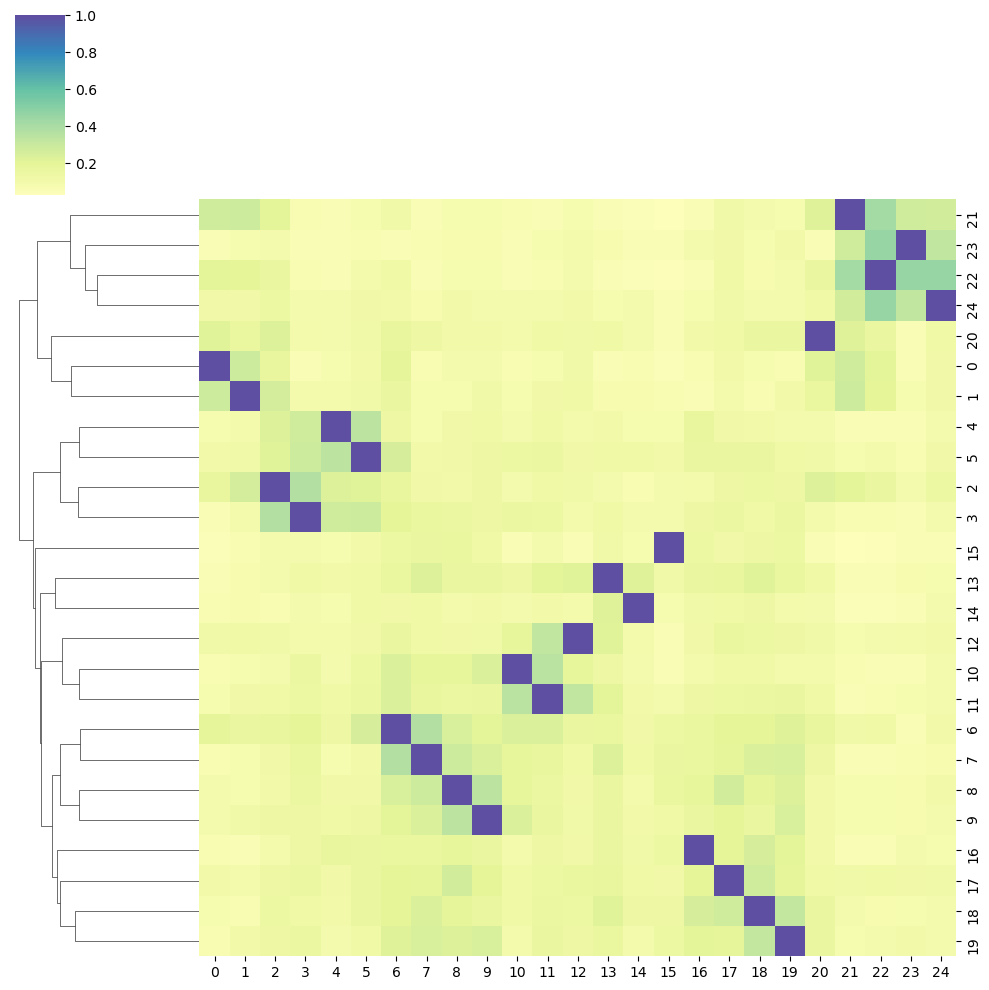

In [31]:
sns.clustermap(TFIDF_SIM, cmap='Spectral', center=0, col_cluster=None);

<Figure size 640x480 with 0 Axes>

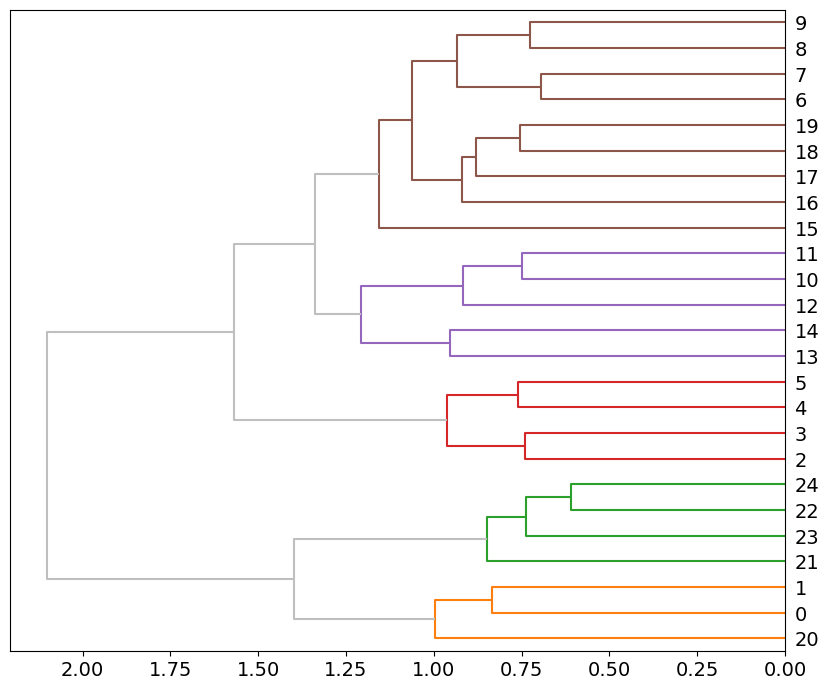

In [32]:
tfidf_hac = HAC(TFIDF_SIM)
tfidf_hac.color_thresh = 1.25
tfidf_hac.plot()

In [33]:
tfidf_hac.get_cluster_labels()

In [34]:
DOC['hac_label'] = tfidf_hac.CLUSTER_LABELS

In [35]:
k = len(set(tfidf_hac.CLUSTER_LABELS))
k

5

In [36]:
CLUSTER = DOC.hac_label.value_counts().to_frame('n_chunks')

In [37]:
CLUSTER

,n_chunks
hac_label,
4,9
5,5
3,4
1,4
2,3


In [38]:
label_col = "hac_label"

In [39]:
CLUSTER['gloss'] = TFIDF.join(DOC[label_col]).groupby(label_col).mean().idxmax(1)
CLUSTER['top_terms'] = TFIDF.join(DOC[label_col]).groupby(label_col).mean().apply(lambda x: ', '.join(x.sort_values(ascending=False).head(7).index), axis=1)

In [40]:
CLUSTER.sort_index()

,n_chunks,gloss,top_terms
hac_label,,,
1,4,b'alam,"b'alam, tojil, k'itze, b'alam k'itze, b'alam a..."
2,3,ulew,"ulew, saqil, kaj, winaq, puch, k'ajolom, alom"
3,4,wuqub kaqix,"wuqub kaqix, kaqix, sipakna, k'ajolab, ri sipa..."
4,9,xib'alb'a,"xib'alb'a, kame, ajpu, jun ajpu, ajawab, xcha,..."
5,5,kati't,"kati't, ati't, ch'o, xpeq, qati't, ix qati't, ..."


In [41]:
# pca_engine = PCA(n_components=k + (k % 2))
pca_engine = PCA(n_components=10)
PCAX = pd.DataFrame(pca_engine.fit_transform(TFIDF), index=TFIDF.index)
PCAX.index.name = 'doc_id'
LOADINGS = pd.DataFrame(pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_), index = TFIDF.columns)
LOADINGS.index.name = 'term_str'

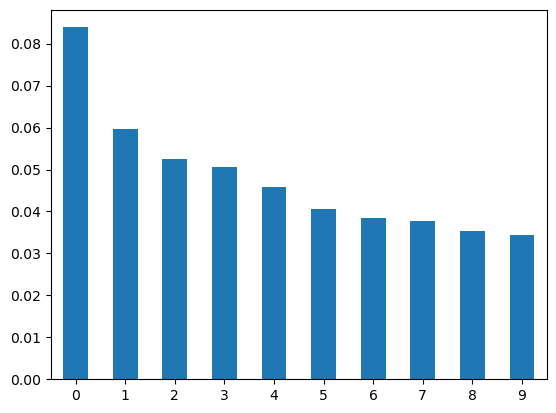

In [42]:
pd.Series(pca_engine.explained_variance_).plot.bar(rot=0);

In [43]:
X0 = DOC.join(PCAX).join(CLUSTER, on=label_col)

def plot_pca(x, y):

    px.scatter(X0, x, y, 
        text=X0.index, 
        height=850, width=950, 
        color=X0.gloss,
        size = [1 for i in range(len(X0))],
        marginal_x='box', 
        marginal_y='box').show()

    quantile = .99
    A = LOADINGS.loc[np.abs(LOADINGS[x]) >= np.abs(LOADINGS[x]).quantile(quantile), x]
    B = LOADINGS.loc[np.abs(LOADINGS[y]) >= np.abs(LOADINGS[y]).quantile(quantile), y]    
    C = pd.concat([A,B], axis=1).index
    
    px.scatter(LOADINGS.loc[C].join(VOCAB), x, y, 
        title=f"Quantile {quantile} Loadings for {x} and {y}",
        opacity=.5,
        text=C, 
        size='n',
        height=850, width=950).show()
    

In [44]:
plot_pca(0,1)

In [45]:
n_topic_terms = 10
nmf_engine = NMF(n_components=k, max_iter=5000, init='nndsvda', solver='mu', beta_loss='kullback-leibler')
THETA = pd.DataFrame(nmf_engine.fit_transform(TFIDF), index=TFIDF.index)
THETA_SIM = pd.DataFrame(cosine_similarity(THETA), index=THETA.index, columns=THETA.index)
PHI = pd.DataFrame(nmf_engine.components_, columns=TFIDF.columns)
TOPIC = PHI.T.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(n_topic_terms).index)).T.to_frame('top_terms')
TOPIC.index.name = 'topic_id'
DOC[f'top_topic_{k}'] = THETA.idxmax(1).values

In [46]:
with open("topics.md", "w") as outfile:
    TOPIC.to_markdown(outfile)

In [47]:
TOPIC['gloss'] = PHI.idxmax(1)

In [48]:
TOPIC

,top_terms,gloss
topic_id,,
0,"xib'alb'a, kame, ajpu, xcha, jun ajpu, ajawab,...",xib'alb'a
1,"b'alam, tojil, b'alam k'itze, k'itze, b'alam a...",b'alam
2,"wuqub kaqix, kaqix, sipakna, k'ajolab, ri sipa...",wuqub kaqix
3,"ulew, tz'ikin, puch, winaq, kaj, saqil, k'ajol...",ulew
4,"kati't, ati't, ch'o, qati't, ix qati't, b'atz ...",kati't


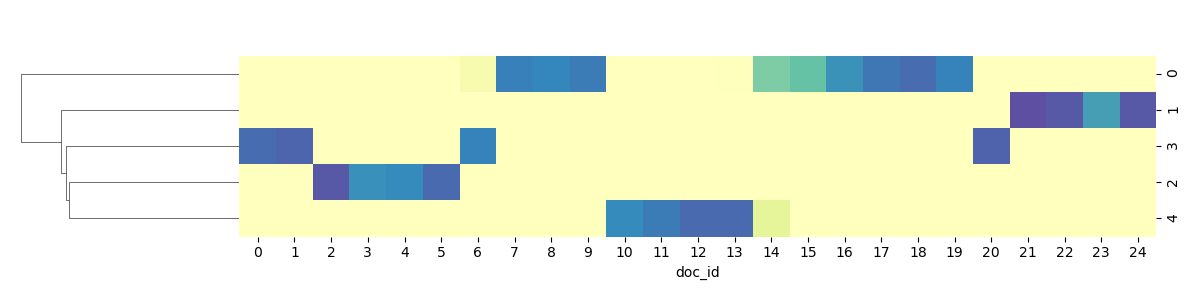

In [49]:
fig = sns.clustermap(THETA.T, 
                     cmap='Spectral', method='ward', 
                     cbar_pos=None, center=0, 
                     row_cluster=True, 
                     col_cluster=False,
                    figsize=(12,3))